In [6]:
import geopandas as gpd
import rasterio
import pandas as pd
import numpy as np

In [7]:
# gdf = gpd.read_file("gadm41_THA_shp/gadm41_THA_2.shp")
# gdf.info()

# north_provinces = [
#     "Chiang Mai","Chiang Rai","Lampang","Lamphun","Mae Hong Son",
#     "Nan","Phayao","Phrae","Uttaradit","Tak","Sukhothai",
#     "Phitsanulok","Kamphaeng Phet","Phichit","Phetchabun"
# ]

# north = gdf[gdf["NAME_1"].isin(north_provinces)]

# north.info()
# north.to_file("north_aumphur_thailand.shp")

-----------------------------------------------------------------------------------------------------------------------------------------------------------

# Load shapefiles

In [8]:
import geopandas as gpd
import pandas as pd

years = [2023, 2024, 2025]

fire_all = []

for y in years:
    df = gpd.read_file(f"../data/MODIS_{y}.shp")
    df["ACQ_DATE"] = pd.to_datetime(df["ACQ_DATE"])
    df["fire"] = 1
    fire_all.append(df)

fire_df = pd.concat(fire_all, ignore_index=True)

In [9]:
fire_all[0].info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 29173 entries, 0 to 29172
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   LATITUDE    29173 non-null  float64       
 1   LONGITUDE   29173 non-null  float64       
 2   BRIGHTNESS  29173 non-null  float64       
 3   SCAN        29173 non-null  float64       
 4   TRACK       29173 non-null  float64       
 5   ACQ_DATE    29173 non-null  datetime64[ms]
 6   ACQ_TIME    29173 non-null  object        
 7   SATELLITE   29173 non-null  object        
 8   INSTRUMENT  29173 non-null  object        
 9   CONFIDENCE  29173 non-null  int32         
 10  VERSION     29173 non-null  object        
 11  BRIGHT_T31  29173 non-null  float64       
 12  FRP         29173 non-null  float64       
 13  DAYNIGHT    29173 non-null  object        
 14  TYPE        29173 non-null  int64         
 15  geometry    29173 non-null  geometry      
 16  fire        29

In [10]:
fire_all[0].head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry,fire
0,6.2859,101.2527,314.1,1.3,1.1,2023-01-01,0642,Aqua,MODIS,66,61.03,296.5,11.1,D,0,POINT (101.2527 6.2859),1
1,6.2841,101.2413,317.3,1.3,1.1,2023-01-01,0642,Aqua,MODIS,71,61.03,296.0,15.4,D,0,POINT (101.2413 6.2841),1
2,9.1707,99.8283,310.2,1.4,1.2,2023-01-01,0642,Aqua,MODIS,51,61.03,293.6,10.9,D,0,POINT (99.8283 9.1707),1
3,12.0924,102.7745,306.8,1.0,1.0,2023-01-01,0643,Aqua,MODIS,19,61.03,291.1,4.1,D,0,POINT (102.7745 12.0924),1
4,12.8855,101.0871,314.5,1.1,1.0,2023-01-01,0643,Aqua,MODIS,36,61.03,300.9,4.0,D,0,POINT (101.0871 12.8855),1


In [11]:
fire_all[0][fire_all[0]["fire"] == 0].head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry,fire


# Check rasters

In [12]:
import rasterio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. โหลดข้อมูล Raster เพื่อดูขอบเขต (Bounds)
raster_path = "../data/GEE_FIRE/fire_feature_2023_01.tif"
with rasterio.open(raster_path) as src:
    raster_bounds = src.bounds
    print(f"Raster Bounds: {raster_bounds}")

# 2. กรอง GeoDataFrame (fire_df) ให้เหลือเฉพาะจุดที่อยู่ในขอบเขตของ Raster
# โดยอ้างอิงจาก BoundingBox: left=97.34, bottom=15.17, right=101.79, top=20.46
fire_df_filtered = fire_df[
    (fire_df['LONGITUDE'] >= raster_bounds.left) & 
    (fire_df['LONGITUDE'] <= raster_bounds.right) &
    (fire_df['LATITUDE'] >= raster_bounds.bottom) & 
    (fire_df['LATITUDE'] <= raster_bounds.top)
].copy()

print(f"จำนวนข้อมูลก่อนกรอง: {len(fire_df)}")
print(f"จำนวนข้อมูลหลังกรองตามขอบเขตพื้นที่: {len(fire_df_filtered)}")

Raster Bounds: BoundingBox(left=97.34413913304371, bottom=15.177935040483437, right=101.79079978943534, top=20.46541880281094)
จำนวนข้อมูลก่อนกรอง: 67932
จำนวนข้อมูลหลังกรองตามขอบเขตพื้นที่: 40180


In [13]:
feature_names = ['ndvi', 'ndwi', 'nbr', 'blue', 'green', 'red', 'nir', 'swir1', 'swir2', 
                 'temp', 'soil_moisture', 'wind_u', 'wind_v', 'elev', 'slope', 'aspect', 'landcover']

def sample_raster_precise(df, raster_path):
    with rasterio.open(raster_path) as src:
        # ดึงพิกัดเฉพาะจุดที่ผ่านการกรองแล้ว
        coords = [(x, y) for x, y in zip(df.LONGITUDE, df.LATITUDE)]
        # สกัดค่าจาก Raster
        samples = np.array(list(src.sample(coords)))

    # เก็บค่าลงใน DataFrame
    for i, name in enumerate(feature_names):
        df[name] = samples[:, i]
    
    return df

# รันการสกัดค่า
fire_df_sampled = sample_raster_precise(fire_df_filtered, raster_path)

In [14]:
# 1. ตรวจสอบว่าในแต่ละคอลัมน์มี NaN เท่าไหร่
print("จำนวนค่า NaN ในแต่ละคุณลักษณะ:")
print(fire_df_sampled[feature_names].isna().sum())

# 2. ลบแถวที่มีค่า NaN ทิ้ง (เนื่องจากไม่มีข้อมูลพิกเซลที่ไม่มีเมฆในเดือนนั้น)
df_final = fire_df_sampled.dropna(subset=feature_names)

print(f"จำนวนข้อมูลที่พร้อมใช้งานจริง (ไม่มี NaN): {len(df_final)}")

# 3. ดูค่าทางสถิติของข้อมูลที่สกัดได้
if len(df_final) > 0:
    print("\nสรุปค่าทางสถิติของข้อมูลที่สกัดได้จริง:")
    print(df_final[feature_names].describe())
else:
    print("\nคำเตือน: ไม่เหลือข้อมูลที่สมบูรณ์เลยในเดือนนี้ (อาจเพราะเมฆบังทั้งพื้นที่)")

จำนวนค่า NaN ในแต่ละคุณลักษณะ:
ndvi             9535
ndwi             9535
nbr              9535
blue             9535
green            9535
red              9535
nir              9535
swir1            9535
swir2            9535
temp             9535
soil_moisture    9535
wind_u           9535
wind_v           9535
elev             9535
slope            9535
aspect           9535
landcover        9535
dtype: int64
จำนวนข้อมูลที่พร้อมใช้งานจริง (ไม่มี NaN): 30645

สรุปค่าทางสถิติของข้อมูลที่สกัดได้จริง:
               ndvi          ndwi           nbr          blue         green  \
count  30645.000000  30645.000000  30645.000000  30645.000000  30645.000000   
mean       0.392177     -0.378506      0.247786   1385.714355   1576.775024   
std        0.096743      0.068098      0.120057    162.290192    184.006577   
min       -0.126253     -0.553033     -0.277428   1109.000000   1247.500000   
25%        0.332692     -0.425029      0.175137   1277.000000   1453.000000   
50%        0.41316

# Sample Function

In [15]:
feature_names = ['ndvi', 'ndwi', 'nbr', 'blue', 'green', 'red', 'nir', 'swir1', 'swir2', 'temp', 'soil_moisture', 'wind_u', 'wind_v', 'elev', 'slope', 'aspect', 'landcover']

def sample_raster(df, raster_path):
    with rasterio.open(raster_path) as src:
        coords = [(x, y) for x, y in zip(df.LONGITUDE, df.LATITUDE)]
        samples = np.array(list(src.sample(coords)))
        
        # ตรวจสอบว่ามีค่าที่ไม่ใช่ nan หรือ 0 บ้างไหม
        print(f"Non-zero samples: {np.count_nonzero(samples)}") 
        
    for i, name in enumerate(feature_names):
        df[name] = samples[:, i]
    return df

# Merge Rasters

In [16]:
import rasterio
import pandas as pd
import numpy as np
import glob

raster_files = sorted(glob.glob("../data/GEE_FIRE/fire_feature_*.tif"))

all_fire_data = []
feature_names = ['ndvi', 'ndwi', 'nbr', 'blue', 'green', 'red', 'nir', 'swir1', 'swir2', 
                 'temp', 'soil_moisture', 'wind_u', 'wind_v', 'elev', 'slope', 'aspect', 'landcover']

for raster_path in raster_files:
    # 1. โหลดขอบเขตของ Raster ปัจจุบัน
    with rasterio.open(raster_path) as src:
        raster_bounds = src.bounds
        # print(f"Processing: {raster_path}") # เปิดไว้ดู track การทำงานได้
        
        # 2. แยกปีและเดือนจากชื่อไฟล์ (สมมติชื่อไฟล์คือ ...fire_feature_2023_01.tif)
        name = raster_path.split("/")[-1]
        parts = name.replace(".tif","").split("_")
        year = int(parts[3])
        month = int(parts[4])

        # 3. กรองข้อมูลจุด (fire_df) เฉพาะที่ตรงกับปี/เดือน และ "ต้องอยู่ในขอบเขตพื้นที่" ของ Raster นี้
        subset = fire_df[
            (fire_df["ACQ_DATE"].dt.year == year) &
            (fire_df["ACQ_DATE"].dt.month == month) &
            (fire_df['LONGITUDE'] >= raster_bounds.left) & 
            (fire_df['LONGITUDE'] <= raster_bounds.right) &
            (fire_df['LATITUDE'] >= raster_bounds.bottom) & 
            (fire_df['LATITUDE'] <= raster_bounds.top)
        ].copy()

        if len(subset) == 0:
            continue

        # 4. สกัดค่า (Sampling) จาก Raster
        coords = [(x, y) for x, y in zip(subset.LONGITUDE, subset.LATITUDE)]
        samples = np.array(list(src.sample(coords)))

        # 5. เก็บค่าลงคอลัมน์
        for i, name_feat in enumerate(feature_names):
            subset[name_feat] = samples[:, i]

        all_fire_data.append(subset)

# 6. รวมข้อมูลทั้งหมด
if all_fire_data:
    df_fire_merged = pd.concat(all_fire_data, ignore_index=True)
    
    # 7. ลบแถวที่เป็น NaN ทิ้ง (พิกเซลที่ถูกเมฆบังจนไม่มีข้อมูลจริงใน GEE)
    df_fire_final = df_fire_merged.dropna(subset=feature_names)
    
    print(f"รวมข้อมูลเสร็จสิ้น!")
    print(f"จำนวนข้อมูลทั้งหมดหลังสกัดค่า: {len(df_fire_merged)}")
    print(f"จำนวนข้อมูลที่พร้อมใช้งาน (ลบ NaN): {len(df_fire_final)}")
    
    # ตรวจสอบค่าทางสถิติเพื่อความมั่นใจ
    print("\nสรุปค่าทางสถิติ (ตัวอย่าง NDVI):")
    print(df_fire_final['ndvi'].describe())
else:
    print("ไม่พบข้อมูลที่ตรงเงื่อนไขขอบเขตพื้นที่และเวลา")

รวมข้อมูลเสร็จสิ้น!
จำนวนข้อมูลทั้งหมดหลังสกัดค่า: 40180
จำนวนข้อมูลที่พร้อมใช้งาน (ลบ NaN): 30638

สรุปค่าทางสถิติ (ตัวอย่าง NDVI):
count    30638.000000
mean         0.314882
std          0.091262
min         -0.165037
25%          0.251122
50%          0.312944
75%          0.375936
max          0.631384
Name: ndvi, dtype: float64


# Non-fire data

In [17]:
import numpy as np
import pandas as pd
from shapely.geometry import Point
import geopandas as gpd

# สมมติฐาน: คุณมีขอบเขตพื้นที่ศึกษา (เช่น BoundingBox ของภาคเหนือ)
min_lon, min_lat, max_lon, max_lat = 97.34, 15.17, 101.79, 20.46

# กำหนดจำนวนจุด Non-fire ที่ต้องการ (เช่น เท่ากับจุด Fire)
n_non_fire = len(fire_df)

# สุ่มพิกัด
np.random.seed(42)
lons = np.random.uniform(min_lon, max_lon, n_non_fire)
lats = np.random.uniform(min_lat, max_lat, n_non_fire)

# สุ่มเดือนและปี (หรือใช้วันที่แบบสุ่มเต็มรูปแบบ)
years_pool = [2023, 2024, 2025]
months_pool = range(1, 13)

random_years = np.random.choice(years_pool, n_non_fire)
random_months = np.random.choice(months_pool, n_non_fire)

# สร้าง วันที่สุ่ม (ประมาณเป็นวันที่ 1 ของเดือน)
random_dates = [pd.to_datetime(f"{y}-{m:02d}-01") for y, m in zip(random_years, random_months)]

# สร้าง DataFrame
non_fire_data = {
    'LONGITUDE': lons,
    'LATITUDE': lats,
    'ACQ_DATE': random_dates,
    'fire': 0  # กำหนดเป็น Non-fire
}
non_fire_df = pd.DataFrame(non_fire_data)

In [18]:
all_non_fire_data = []

# ใช้ลูปเดียวกับที่ใช้ดึงข้อมูล Fire
for raster_path in raster_files:
    with rasterio.open(raster_path) as src:
        raster_bounds = src.bounds
        # print(f"Processing: {raster_path}") # เปิดไว้ดู track การทำงานได้
        
        # 2. แยกปีและเดือนจากชื่อไฟล์ (สมมติชื่อไฟล์คือ ...fire_feature_2023_01.tif)
        name = raster_path.split("/")[-1]
        parts = name.replace(".tif","").split("_")
        year = int(parts[3])
        month = int(parts[4])

        # 3. กรองข้อมูลจุด (fire_df) เฉพาะที่ตรงกับปี/เดือน และ "ต้องอยู่ในขอบเขตพื้นที่" ของ Raster นี้
        subset = non_fire_df[
            (non_fire_df["ACQ_DATE"].dt.year == year) &
            (non_fire_df["ACQ_DATE"].dt.month == month) &
            (non_fire_df['LONGITUDE'] >= raster_bounds.left) &
            (non_fire_df['LONGITUDE'] <= raster_bounds.right) &
            (non_fire_df['LATITUDE'] >= raster_bounds.bottom) &
            (non_fire_df['LATITUDE'] <= raster_bounds.top)
        ].copy()

        if len(subset) > 0:
            all_non_fire_data.append(subset)

        # 4. สกัดค่า (Sampling) จาก Raster
        coords = [(x, y) for x, y in zip(subset.LONGITUDE, subset.LATITUDE)]
        samples = np.array(list(src.sample(coords)))

        # 5. เก็บค่าลงคอลัมน์
        for i, name_feat in enumerate(feature_names):
            subset[name_feat] = samples[:, i]

        all_fire_data.append(subset)

df_non_fire_merged = pd.concat(all_non_fire_data, ignore_index=True)
df_non_fire_final = df_non_fire_merged.dropna(subset=feature_names)

In [19]:
# รวมข้อมูลทั้งหมด
df_final_model = pd.concat([df_fire_final, df_non_fire_final], ignore_index=True)

# สับเปลี่ยนลำดับ (Shuffle) ข้อมูล
df_final_model = df_final_model.sample(frac=1, random_state=42).reset_index(drop=True)

In [20]:
df_non_fire_final.head()

,LONGITUDE,LATITUDE,ACQ_DATE,fire,ndvi,ndwi,nbr,blue,green,red,...,swir1,swir2,temp,soil_moisture,wind_u,wind_v,elev,slope,aspect,landcover
4,101.338566,16.699354,2023-01-01,0,0.467528,-0.411034,0.325225,1425.0,1660.0,1443.0,...,3017.0,2025.0,21.763477,0.191880,-0.977065,-0.751237,276.0,8.0,263.0,10.0
5,100.148567,17.667852,2023-01-01,0,0.221081,-0.263686,0.050684,1672.0,1836.0,2010.0,...,3324.0,2847.0,23.461777,0.214341,-0.556135,-0.468357,71.0,1.0,220.0,50.0
6,101.300524,19.049868,2023-01-01,0,0.480703,-0.434051,0.361070,1241.0,1446.0,1285.0,...,2558.0,1720.0,17.849918,0.288818,-0.443147,-0.045596,1027.0,12.0,277.0,10.0
8,100.277878,17.556326,2023-01-01,0,0.277352,-0.293276,0.044914,1584.0,1729.0,1790.0,...,3448.0,2892.0,22.971226,0.226130,-0.687185,-0.453407,93.0,1.0,341.0,10.0
10,99.071947,16.743671,2023-01-01,0,0.428040,-0.389415,0.269755,1258.5,1433.5,1306.5,...,2798.0,1876.0,21.773060,0.273015,-0.520762,0.553614,227.0,1.0,19.0,10.0


In [21]:
df_non_fire_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37809 entries, 4 to 67757
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   LONGITUDE      37809 non-null  float64       
 1   LATITUDE       37809 non-null  float64       
 2   ACQ_DATE       37809 non-null  datetime64[ns]
 3   fire           37809 non-null  int64         
 4   ndvi           37809 non-null  float32       
 5   ndwi           37809 non-null  float32       
 6   nbr            37809 non-null  float32       
 7   blue           37809 non-null  float32       
 8   green          37809 non-null  float32       
 9   red            37809 non-null  float32       
 10  nir            37809 non-null  float32       
 11  swir1          37809 non-null  float32       
 12  swir2          37809 non-null  float32       
 13  temp           37809 non-null  float32       
 14  soil_moisture  37809 non-null  float32       
 15  wind_u         37809 non

# Combine Dataset

In [22]:
df = pd.concat([df_fire_final, df_non_fire_final], ignore_index=True)
df = df.dropna()

df["month"] = df["ACQ_DATE"].dt.month
df["year"] = df["ACQ_DATE"].dt.year

In [23]:
print(df.head())
print(df.describe())
print(df["fire"].value_counts())

   LATITUDE  LONGITUDE  BRIGHTNESS  SCAN  TRACK   ACQ_DATE ACQ_TIME SATELLITE  \
0   15.3352   101.1958       316.7   1.0    1.0 2023-01-01     0644      Aqua   
1   15.9527   100.5264       323.3   1.1    1.0 2023-01-01     0644      Aqua   
2   15.9512   100.5164       326.5   1.1    1.0 2023-01-01     0644      Aqua   
3   16.1400   100.6051       319.9   1.1    1.0 2023-01-01     0644      Aqua   
4   16.1170   100.4562       315.4   1.1    1.0 2023-01-01     0644      Aqua   

  INSTRUMENT  CONFIDENCE  ...       temp  soil_moisture    wind_u    wind_v  \
0      MODIS        49.0  ...  23.827732       0.167730 -2.874125 -0.635948   
1      MODIS        77.0  ...  24.095718       0.132930 -1.286884 -0.055150   
2      MODIS        80.0  ...  24.095718       0.132930 -1.286884 -0.055150   
3      MODIS        74.0  ...  23.965410       0.131955 -1.273284 -0.151570   
4      MODIS        39.0  ...  24.084709       0.140155 -1.073631 -0.011908   

   elev slope  aspect  landcover  mont

# Visualization

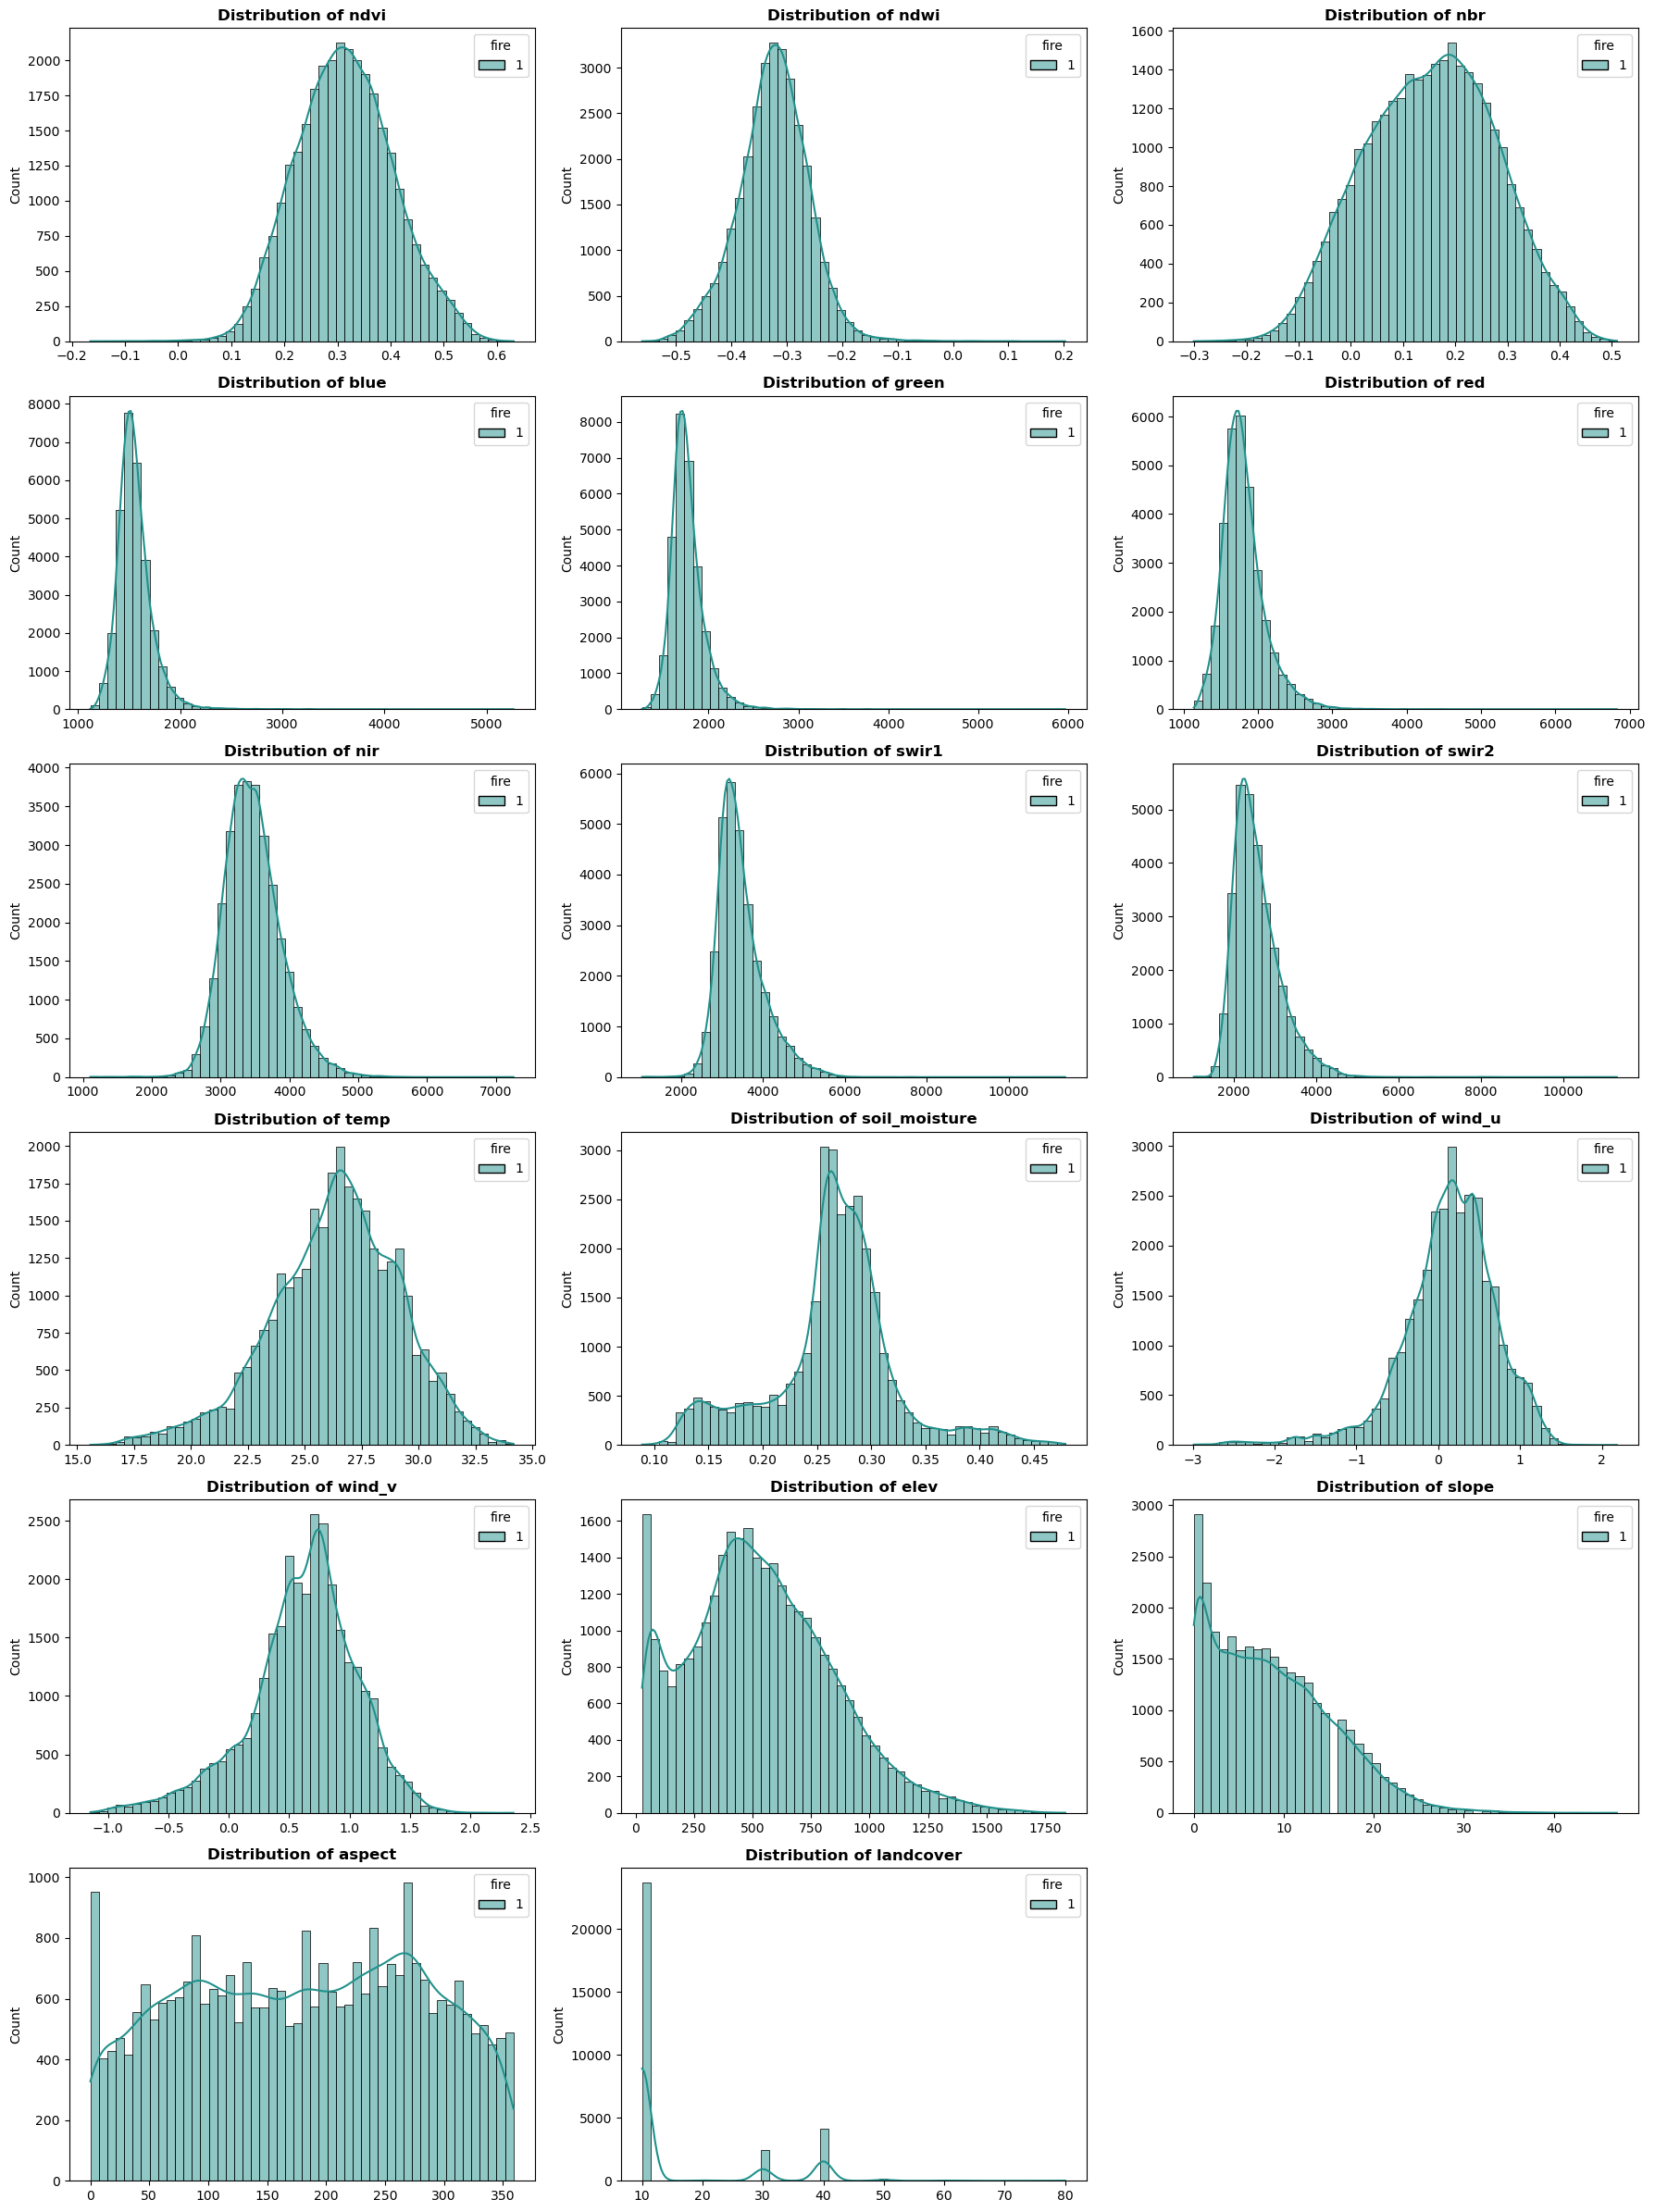

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# รายชื่อฟีเจอร์ตามที่คุณระบุ
feature_names = ['ndvi', 'ndwi', 'nbr', 'blue', 'green', 'red', 'nir', 'swir1', 'swir2', 
                 'temp', 'soil_moisture', 'wind_u', 'wind_v', 'elev', 'slope', 'aspect', 'landcover']

# ตั้งค่าจำนวนแถวและคอลัมน์ของ Subplots
n_features = len(feature_names)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols  # คำนวณจำนวนแถวที่ต้องใช้

# สร้างพื้นที่สำหรับกราฟ
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()  # แปลง array ของ axes ให้เป็นแนวราบเพื่อให้เรียกใช้ง่าย

for i, col in enumerate(feature_names):
    # พล็อตลงในตำแหน่ง axes[i]
    sns.histplot(data=df_fire_final, x=col, hue="fire", bins=50, kde=True, ax=axes[i], palette="viridis")
    axes[i].set_title(f"Distribution of {col}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("") # ลบชื่อแกน x ออกเพื่อความสวยงาม (เพราะใช้หัวข้อระบุแล้ว)

# ลบพื้นที่กราฟว่างที่เหลือทิ้ง (กรณีจำนวนฟีเจอร์ไม่ลงตัวกับตาราง)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # ปรับระยะห่างระหว่างกราฟให้เหมาะสม
plt.show()

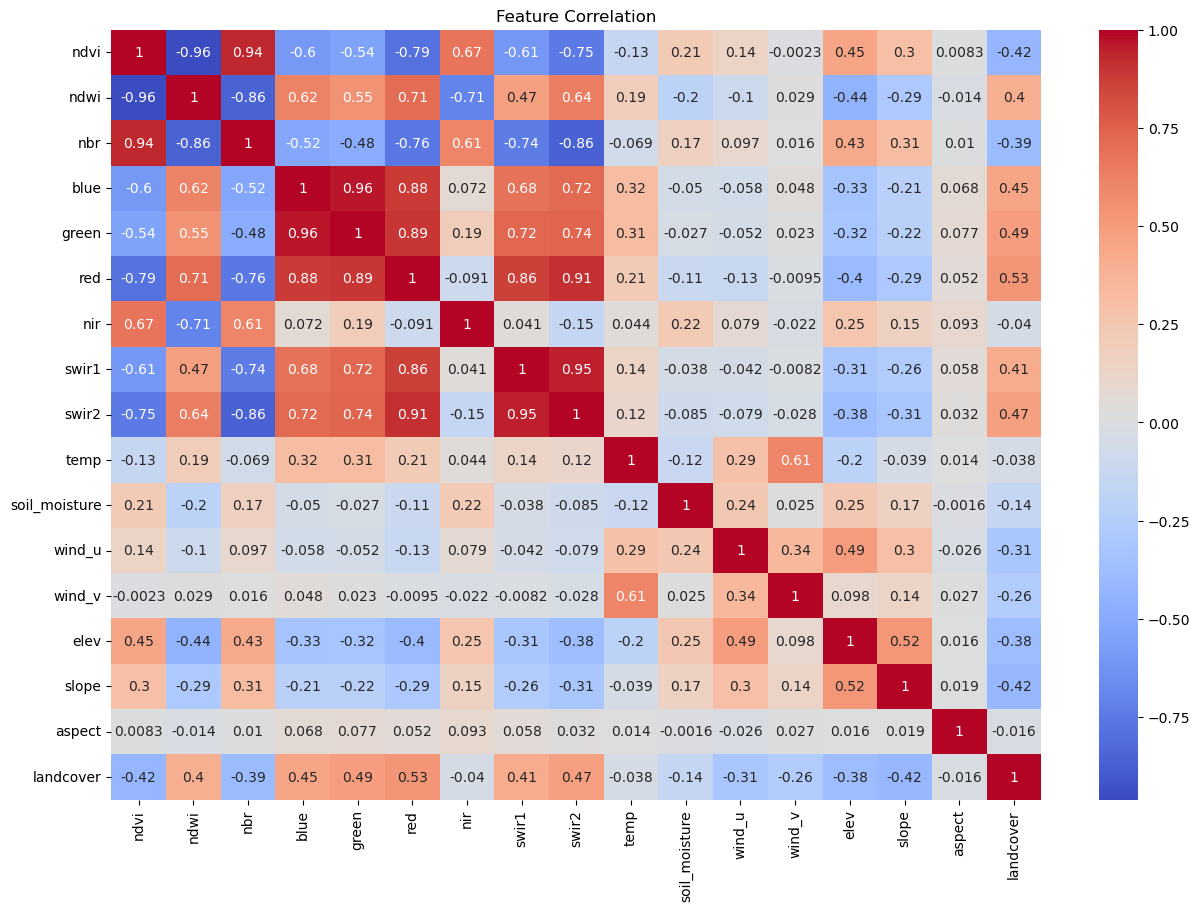

In [25]:
plt.figure(figsize=(15,10))
sns.heatmap(df[feature_names].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

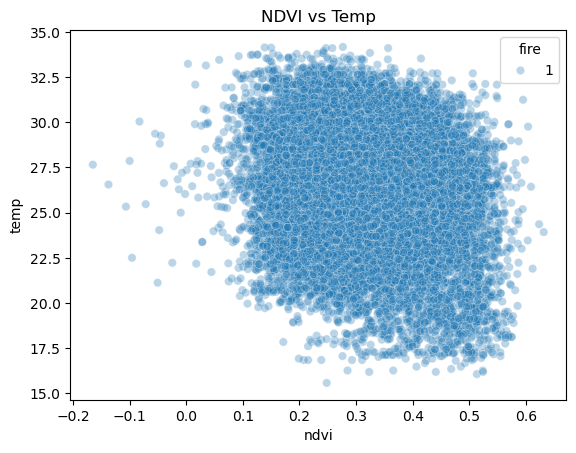

In [26]:
plt.figure()
sns.scatterplot(data=df, x="ndvi", y="temp", hue="fire", alpha=0.3)
plt.title("NDVI vs Temp")
plt.show()

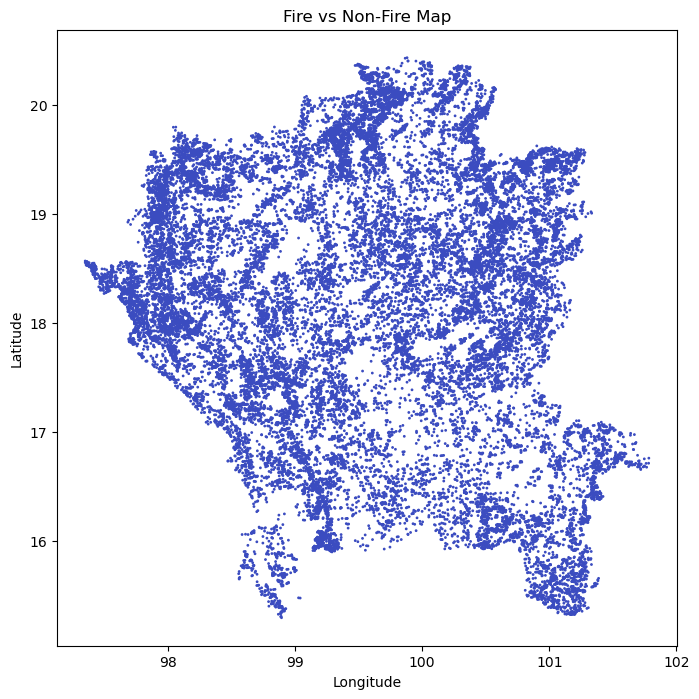

In [27]:
plt.figure(figsize=(8,8))

plt.scatter(df["LONGITUDE"], df["LATITUDE"],
            c=df["fire"], cmap="coolwarm", s=1)

plt.title("Fire vs Non-Fire Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

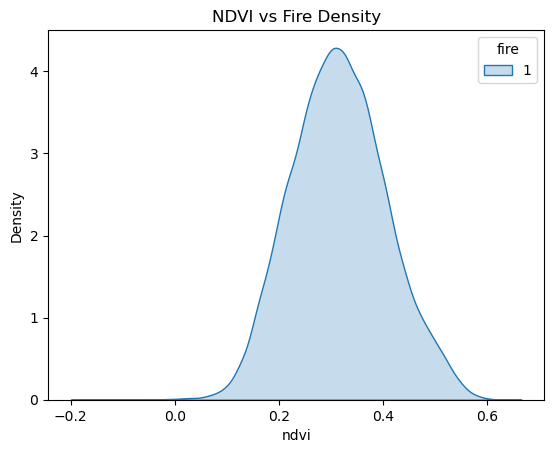

In [28]:
sns.kdeplot(data=df, x="ndvi", hue="fire", fill=True)
plt.title("NDVI vs Fire Density")
plt.show()

# Merge Districts

In [30]:
import geopandas as gpd
from shapely.geometry import Point

# 1. แปลง DataFrame ให้เป็น GeoDataFrame
geometry = [Point(xy) for xy in zip(df_fire_final.LONGITUDE, df_fire_final.LATITUDE)]
gdf_fire = gpd.GeoDataFrame(df_fire_final, geometry=geometry, crs="EPSG:4326")

# 2. โหลด Shapefile ระดับอำเภอของไทย
gdf_amphur = gpd.read_file("../gadm41_THA_shp/gadm41_THA_2.shp") 

# 3. ทำ Spatial Join เพื่อจับคู่จุดกับพื้นที่
gdf_joined = gpd.sjoin(gdf_fire, gdf_amphur, how="left", predicate="within")

# ตอนนี้ gdf_joined จะมีคอลัมน์ชื่อจังหวัด (เช่น 'NAME_1') และอำเภอ (เช่น 'NAME_2') เพิ่มเข้ามา
print(gdf_joined.head())

gdf_joined.to_csv("Dataset/df_final_model.csv", index=False)

    LATITUDE  LONGITUDE  BRIGHTNESS  SCAN  TRACK   ACQ_DATE ACQ_TIME  \
0    15.3352   101.1958       316.7   1.0    1.0 2023-01-01     0644   
13   15.9527   100.5264       323.3   1.1    1.0 2023-01-01     0644   
14   15.9512   100.5164       326.5   1.1    1.0 2023-01-01     0644   
15   16.1400   100.6051       319.9   1.1    1.0 2023-01-01     0644   
16   16.1170   100.4562       315.4   1.1    1.0 2023-01-01     0644   

   SATELLITE INSTRUMENT  CONFIDENCE  ...     GID_1      NAME_1  \
0       Aqua      MODIS          49  ...  THA.42_1  Phetchabun   
13      Aqua      MODIS          77  ...  THA.44_1     Phichit   
14      Aqua      MODIS          80  ...  THA.44_1     Phichit   
15      Aqua      MODIS          74  ...  THA.44_1     Phichit   
16      Aqua      MODIS          39  ...  THA.44_1     Phichit   

              NL_NAME_1           NAME_2  VARNAME_2         NL_NAME_2  \
0   อำเภอเมืองเพชรบูรณ์          Si Thep         NA       อำเภอศรีเทพ   
13        จังหวัดพิจิตร 